# EDA - Teen Mental Health Dataset

Este notebook presenta un analisis exploratorio del dataset `Teen_Mental_Health_Dataset.csv`. El objetivo es estudiar la relacion entre habitos digitales, sueno, actividad fisica, rendimiento academico y la variable objetivo `depression_label`.

El analisis parte del borrador inicial y lo reorganiza en un flujo reproducible: carga de datos, validacion, limpieza, feature engineering, visualizacion y contraste estadistico basico.


## 1. Importacion de librerias y configuracion


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.cleaning import clean_data, detect_outliers_iqr
from src.features import build_features
from src.io import load_data, save_data
from src.utils import chi_square_report, missing_values_report
from src.viz import (
    plot_correlation_matrix,
    plot_depression_rate_by_category,
    plot_depression_vs_social_media,
    plot_numeric_distributions,
)

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Teen_Mental_Health_Dataset.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "teen_mental_health_processed.csv"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)


## 2. Carga de datos

Se carga el CSV original desde `data/raw`. Esta version se mantiene sin modificar para conservar una fuente de datos reproducible.


In [2]:
df_raw = load_data(RAW_DATA_PATH)
df_raw.head()


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [3]:
print(f"Filas: {df_raw.shape[0]}")
print(f"Columnas: {df_raw.shape[1]}")
df_raw.info()


Filas: 1200
Columnas: 13
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140

## 3. Validacion inicial

Antes de transformar el dataset se revisan columnas, nulos y duplicados. En esta muestra no aparecen valores nulos ni registros duplicados, pero se mantiene el paso de limpieza dentro del pipeline para que el proyecto sea robusto.


In [4]:
df_raw.columns.tolist()


['age',
 'gender',
 'daily_social_media_hours',
 'platform_usage',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'social_interaction_level',
 'stress_level',
 'anxiety_level',
 'addiction_level',
 'depression_label']

In [5]:
missing_values_report(df_raw)


,missing_values,missing_pct
age,0,0.0
gender,0,0.0
daily_social_media_hours,0,0.0
platform_usage,0,0.0
sleep_hours,0,0.0
screen_time_before_sleep,0,0.0
academic_performance,0,0.0
physical_activity,0,0.0
social_interaction_level,0,0.0
stress_level,0,0.0


**Interpretacion:** El dataset original no presenta valores nulos. Esto permite trabajar sin imputaciones complejas en esta version, aunque el pipeline mantiene una funcion de tratamiento de nulos para que el proyecto sea robusto si cambia la fuente de datos.


In [6]:
print(f"Duplicados: {df_raw.duplicated().sum()}")


Duplicados: 0


**Interpretacion:** No se han encontrado registros duplicados. Por tanto, la eliminacion de duplicados no reduce el numero de filas y el dataset mantiene 1200 observaciones.


## 4. Limpieza y feature engineering

Se normalizan nombres de columnas, se convierten variables categoricas y se crean variables derivadas:

- `heavy_social_media_user`: marca usuarios con 5 o mas horas diarias en redes sociales.
- `sleep_quality`: clasifica el sueno en `poor`, `normal` y `good`.
- `risk_score`: indice heuristico exploratorio basado en redes sociales, sueno, estres, ansiedad y rendimiento academico. No es una metrica clinica.
- `risk_category`: terciles de `risk_score`.


In [7]:
df = clean_data(df_raw)
df = build_features(df)
save_data(df, PROCESSED_DATA_PATH)

df.head()


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,heavy_social_media_user,sleep_quality,risk_score,risk_category
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,1,good,3.3685,low
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,0,good,2.3870,low
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,0,good,1.6020,low
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0,1,normal,4.0730,medium
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0,0,poor,3.9295,medium


**Interpretacion:** Tras la limpieza y el feature engineering, el dataset pasa de 13 columnas originales a 17 columnas. Las nuevas variables (`heavy_social_media_user`, `sleep_quality`, `risk_score` y `risk_category`) ayudan a resumir patrones de uso, descanso y riesgo exploratorio.


In [8]:
print(f"Dataset procesado guardado en: {PROCESSED_DATA_PATH}")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.dtypes


Dataset procesado guardado en: /Users/jobdelgadoiniesta/Documents/EVOLVE/proyecto-github-01/data/processed/teen_mental_health_processed.csv
Filas: 1200 | Columnas: 17


age                            int64
gender                      category
daily_social_media_hours     float64
platform_usage              category
sleep_hours                  float64
screen_time_before_sleep     float64
academic_performance         float64
physical_activity            float64
social_interaction_level    category
stress_level                   int64
anxiety_level                  int64
addiction_level                int64
depression_label               int64
heavy_social_media_user        int64
sleep_quality               category
risk_score                   float64
risk_category               category
dtype: object

## 5. Analisis descriptivo

Se revisan estadisticos generales de las variables numericas y la distribucion de la variable objetivo. El porcentaje de positivos en `depression_label` es bajo, por lo que cualquier comparacion debe interpretarse teniendo en cuenta el desbalance.


In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1200.0,15.928333,2.021947,13.0000,14.000,16.00000,18.000000,19.0000
daily_social_media_hours,1200.0,4.536667,2.029599,1.0000,2.800,4.50000,6.300000,8.0000
sleep_hours,1200.0,6.449417,1.442677,4.0000,5.200,6.50000,7.600000,9.0000
screen_time_before_sleep,1200.0,1.740333,0.716660,0.5000,1.100,1.80000,2.400000,3.0000
academic_performance,1200.0,2.990383,0.576758,2.0000,2.500,2.99000,3.480000,4.0000
physical_activity,1200.0,1.014500,0.582185,0.0000,0.500,1.00000,1.500000,2.0000
stress_level,1200.0,5.445833,2.903290,1.0000,3.000,5.00000,8.000000,10.0000
anxiety_level,1200.0,5.636667,2.859453,1.0000,3.000,6.00000,8.000000,10.0000
addiction_level,1200.0,5.565000,2.830627,1.0000,3.000,6.00000,8.000000,10.0000
depression_label,1200.0,0.025833,0.158704,0.0000,0.000,0.00000,0.000000,1.0000


In [10]:
target_distribution = (
    df["depression_label"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .to_frame()
)
target_distribution


,percentage
depression_label,
0,97.416667
1,2.583333


**Interpretacion:** La variable objetivo esta muy desbalanceada: aproximadamente el 97.42% de los registros pertenecen a la clase 0 y el 2.58% a la clase 1. Este punto es importante porque las comparaciones con `depression_label` deben interpretarse con cautela.


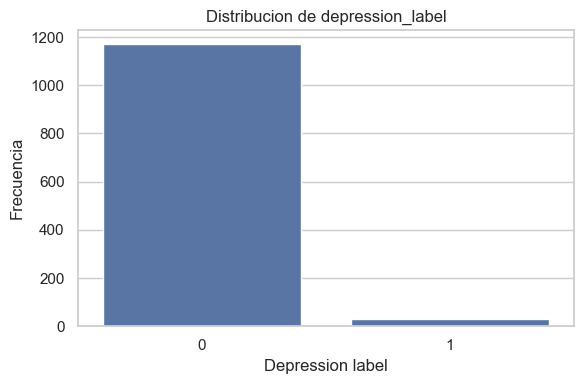

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="depression_label")
plt.title("Distribucion de depression_label")
plt.xlabel("Depression label")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


**Interpretacion:** La grafica confirma visualmente el desbalance de clases. La clase positiva existe, pero representa una proporcion pequena del total; para un modelo predictivo futuro haria falta tratar este desbalance.


## 6. Distribuciones numericas

Los histogramas permiten detectar rangos, concentraciones y posibles variables con distribuciones poco uniformes.


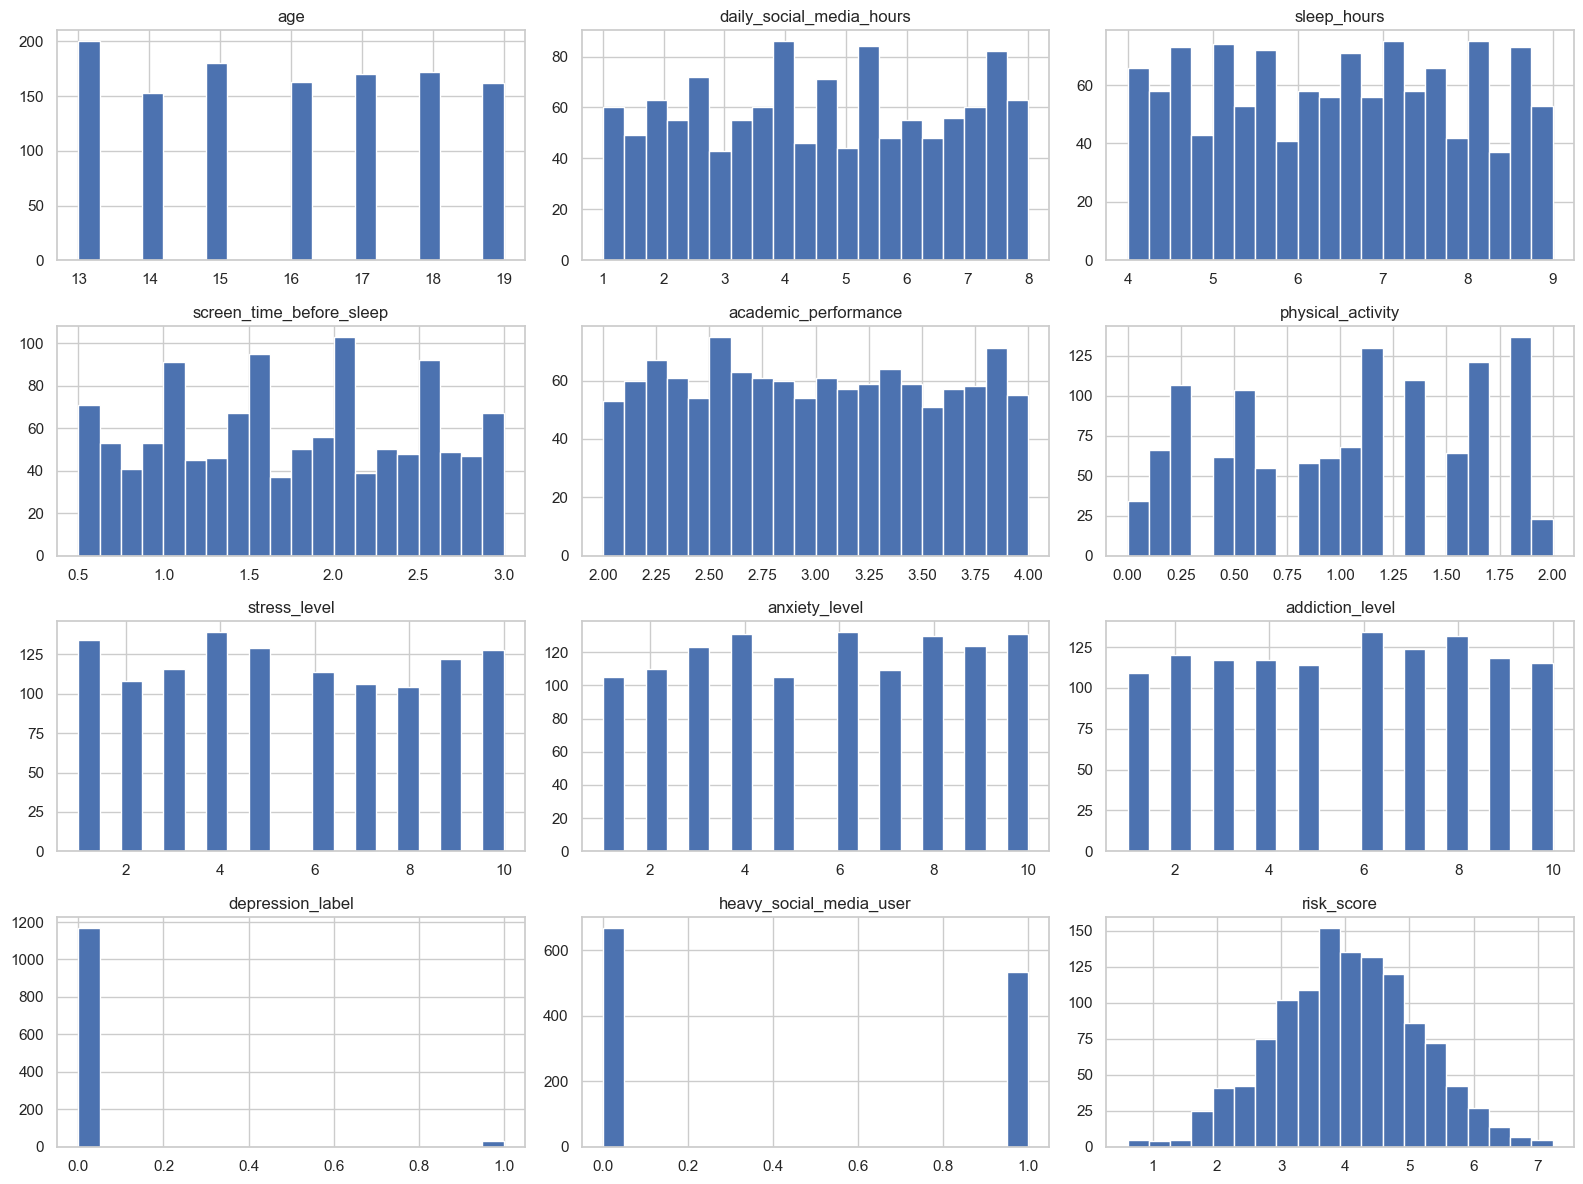

In [12]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
plot_numeric_distributions(df, numeric_cols)


**Interpretacion:** Las variables numericas muestran rangos coherentes con el contexto del dataset: edad adolescente, uso diario de redes sociales entre 1 y 8 horas, sueno entre 4 y 9 horas, y escalas de estres, ansiedad y adiccion entre 1 y 10.


## 7. Variables categoricas

Se revisa la frecuencia de genero, plataforma principal y nivel de interaccion social.


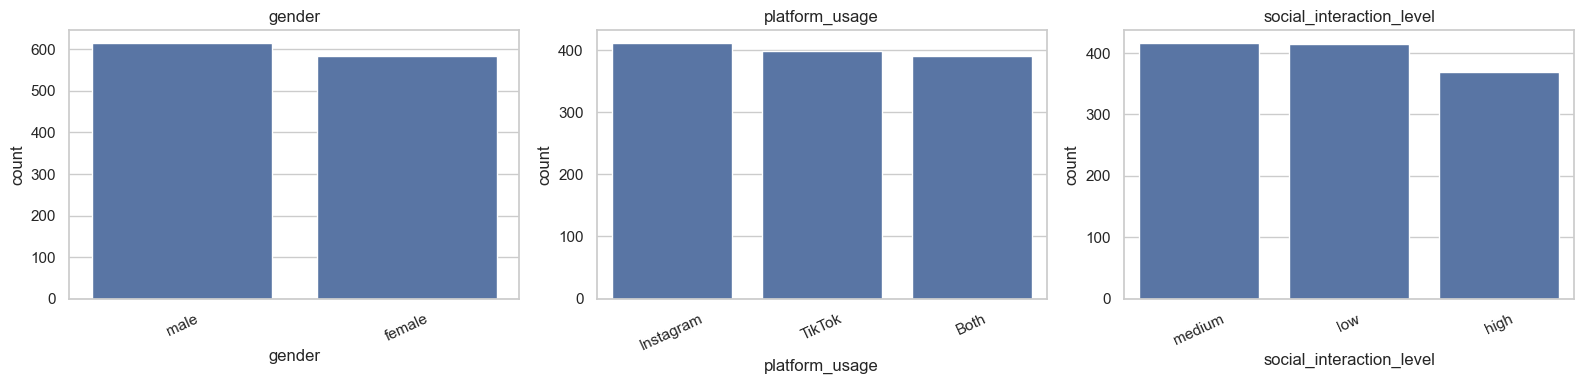

In [13]:
categorical_cols = ["gender", "platform_usage", "social_interaction_level"]

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(16, 4))

for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


**Interpretacion:** Las variables categoricas principales tienen una distribucion razonablemente repartida. No se observa una categoria dominante extrema en genero, plataforma o nivel de interaccion social.


## 8. Correlaciones

La matriz de correlacion ayuda a observar asociaciones lineales entre variables numericas. No implica causalidad, pero orienta el analisis posterior.


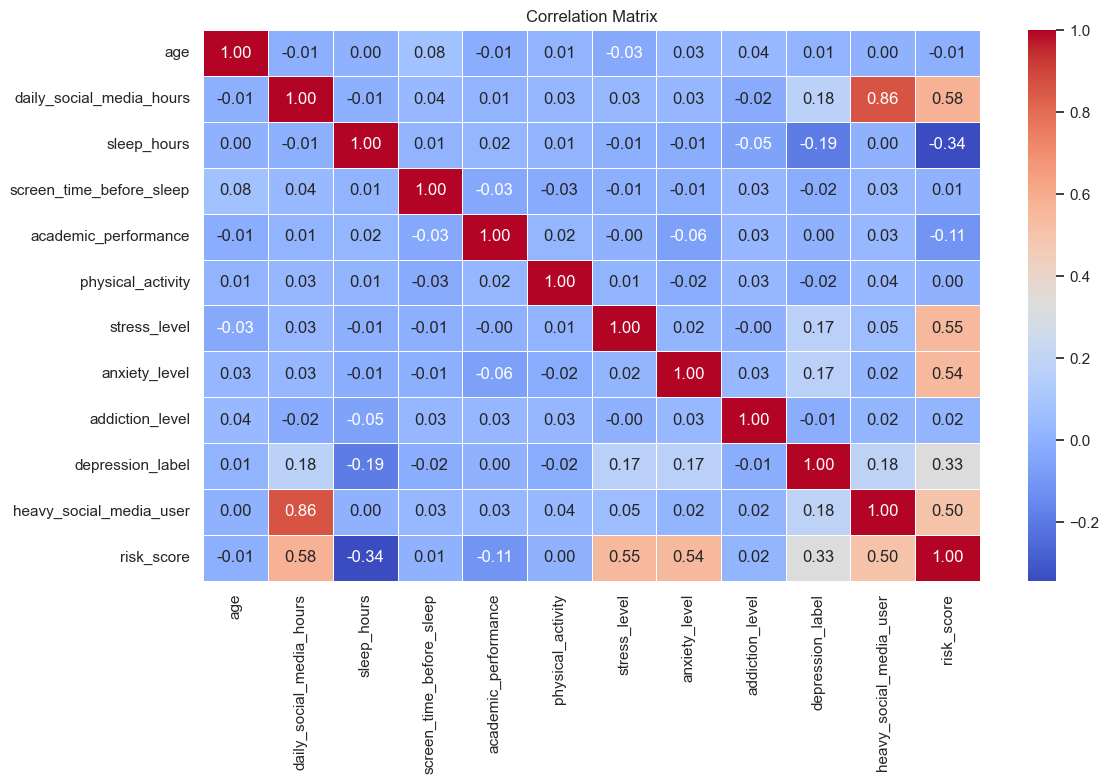

In [14]:
plot_correlation_matrix(df, numeric_cols)


**Interpretacion:** Las correlaciones con `depression_label` son moderadas o bajas. Destacan en positivo `risk_score`, uso intensivo de redes sociales, horas diarias en redes, estres y ansiedad. La relacion mas clara en negativo aparece con `sleep_hours`. Ninguna correlacion por si sola permite inferir causalidad.


In [15]:
(
    df[numeric_cols]
    .corr()["depression_label"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_depression_label")
)


,correlation_with_depression_label
depression_label,1.000000
risk_score,0.332846
heavy_social_media_user,0.182476
daily_social_media_hours,0.175201
stress_level,0.170474
anxiety_level,0.169566
age,0.010973
academic_performance,0.001441
addiction_level,-0.013952
screen_time_before_sleep,-0.016502


**Interpretacion:** Ordenando las correlaciones se observa que el indicador sintetico `risk_score` resume mejor la relacion conjunta con la etiqueta. Aun asi, los valores siguen siendo exploratorios y deben leerse como senales, no como conclusiones causales.


## 9. Relacion entre variables numericas y depression_label

Se comparan algunas variables clave frente a la etiqueta de depresion: uso diario de redes sociales, horas de sueno, estres y ansiedad.


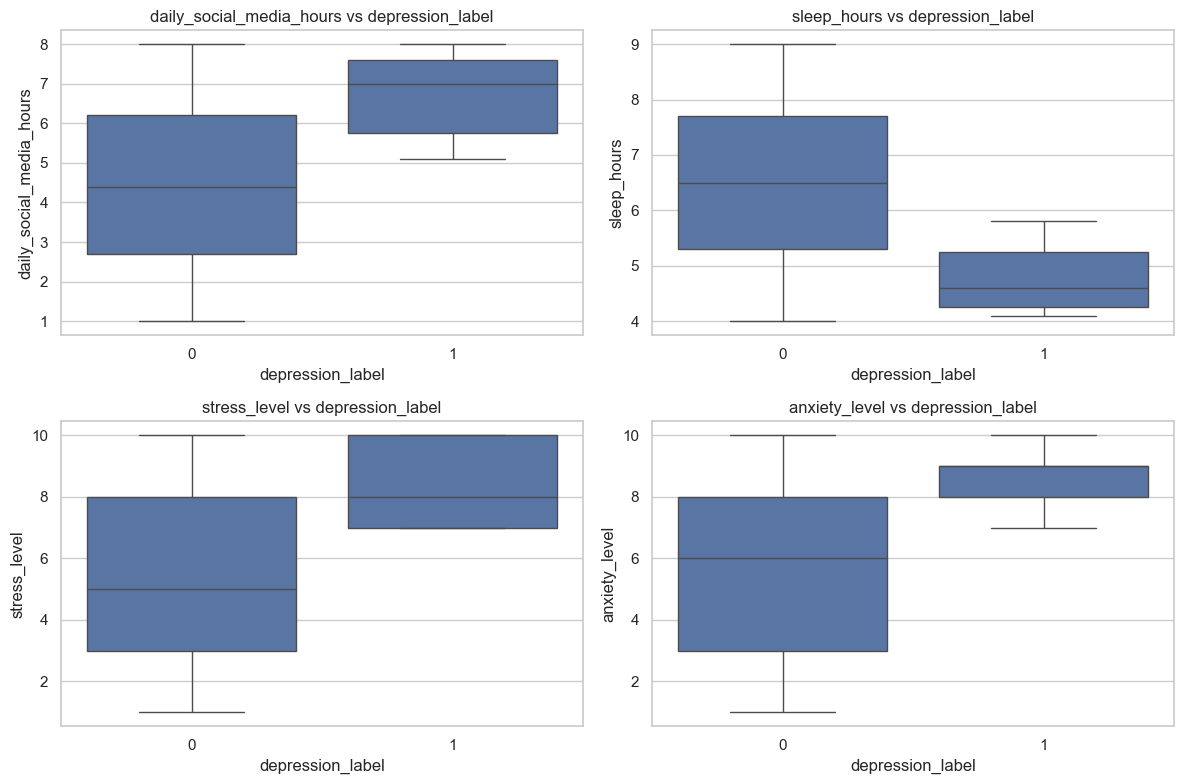

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
variables_to_compare = [
    "daily_social_media_hours",
    "sleep_hours",
    "stress_level",
    "anxiety_level",
]

for ax, col in zip(axes.ravel(), variables_to_compare):
    sns.boxplot(data=df, x="depression_label", y=col, ax=ax)
    ax.set_title(f"{col} vs depression_label")

plt.tight_layout()
plt.show()


**Interpretacion:** Los boxplots muestran que los registros con `depression_label = 1` tienden a concentrarse en mas horas de redes sociales, mayor estres, mayor ansiedad y menos horas de sueno. Por el bajo numero de positivos, estas diferencias deben interpretarse como patrones iniciales.


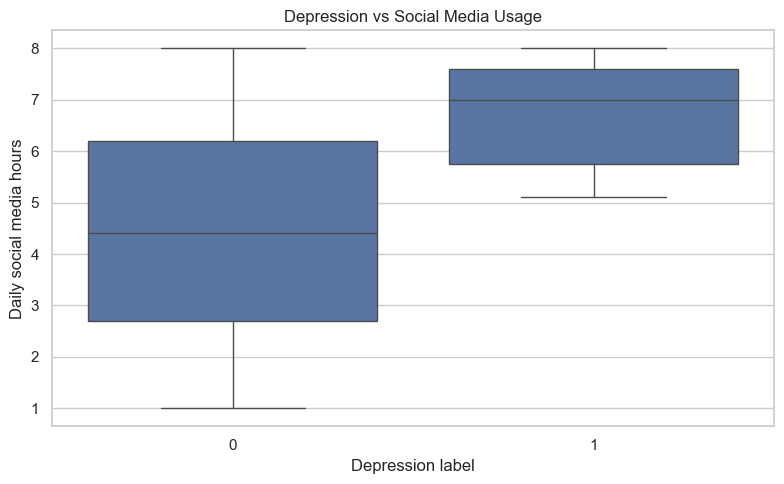

In [17]:
plot_depression_vs_social_media(df)


**Interpretacion:** La comparacion especifica entre depresion y horas de redes sociales refuerza la senal observada en la correlacion: el grupo positivo presenta una tendencia hacia mayor uso diario de redes.


## 10. Relacion entre variables categoricas y depression_label

Se calcula la tasa media de `depression_label` por categoria y se contrastan asociaciones con chi-cuadrado y Cramer's V.


In [18]:
for col in categorical_cols:
    display(
        df.groupby(col, observed=True)["depression_label"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )


,mean,count
gender,,
female,0.029060,585
male,0.022764,615


,mean,count
platform_usage,,
TikTok,0.030151,398
Instagram,0.024331,411
Both,0.023018,391


,mean,count
social_interaction_level,,
medium,0.028846,416
high,0.027100,369
low,0.021687,415


**Interpretacion:** Las tasas medias por categoria son bajas en todos los grupos. Hay diferencias pequenas entre categorias, pero no parecen suficientemente fuertes para sostener una asociacion relevante por si solas.


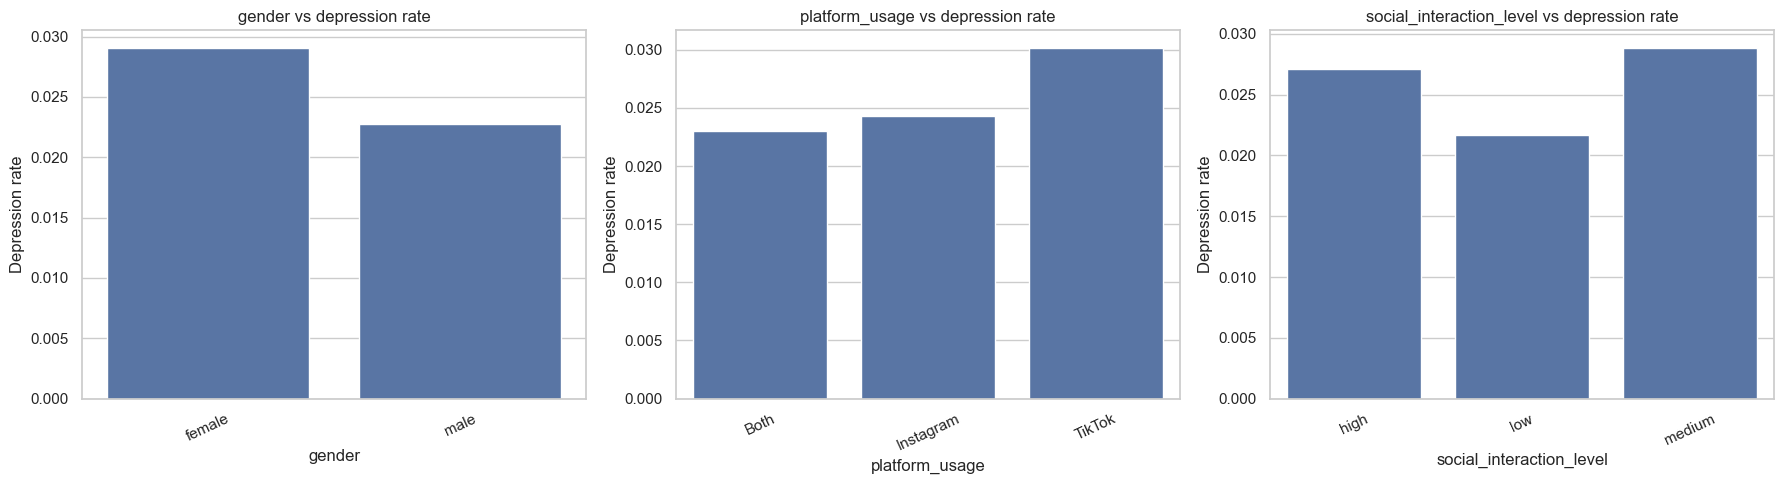

In [19]:
plot_depression_rate_by_category(df, categorical_cols)


**Interpretacion:** Las graficas por categoria muestran variaciones ligeras, no saltos grandes. Esto sugiere que genero, plataforma y nivel de interaccion social no explican de forma fuerte la etiqueta en esta muestra.


In [20]:
chi_square_report(df, categorical_cols, "depression_label")


,feature,chi2,p_value,dof,cramers_v
2,social_interaction_level,0.457123,0.795677,2,0.019518
1,platform_usage,0.454814,0.796596,2,0.019468
0,gender,0.255154,0.613469,1,0.014582


**Interpretacion:** Los p-values son altos y Cramer's V es muy bajo en las tres variables categoricas analizadas. No hay evidencia de asociacion estadistica fuerte entre estas categorias y `depression_label` en este dataset.


## 11. Outliers

Se revisan outliers con el metodo IQR en variables numericas principales. En este contexto no se eliminan automaticamente: primero conviene decidir si representan errores o casos reales.


In [21]:
outlier_summary = []

for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    outlier_summary.append({"feature": col, "outliers": len(outliers)})

pd.DataFrame(outlier_summary).sort_values("outliers", ascending=False)


,feature,outliers
9,depression_label,31
11,risk_score,6
0,age,0
1,daily_social_media_hours,0
2,sleep_hours,0
3,screen_time_before_sleep,0
4,academic_performance,0
5,physical_activity,0
6,stress_level,0
7,anxiety_level,0


**Interpretacion:** El metodo IQR no detecta outliers relevantes en las variables numericas continuas. La variable `depression_label` aparece como outlier por ser binaria y estar desbalanceada: los 31 casos positivos representan el 2.58% del dataset, no errores de datos.


## 12. Conclusiones

### Calidad y estructura del dataset

El dataset contiene 1200 registros y 13 variables originales. Tras el proceso de feature engineering se incorporan 4 variables adicionales: `heavy_social_media_user`, `sleep_quality`, `risk_score` y `risk_category`. No se han detectado valores nulos ni duplicados, por lo que el analisis parte de una base limpia y consistente.

La variable objetivo `depression_label` esta muy desbalanceada: solo 31 registros son positivos, lo que representa aproximadamente el 2.58% de la muestra. Esto significa que la depresion aparece con una frecuencia baja dentro del dataset, pero precisamente por ese desbalance es importante observar que variables diferencian a ese grupo reducido.

### Perfil numerico asociado a depression_label

Comparando las medias entre registros sin depresion (`depression_label = 0`) y con depresion (`depression_label = 1`), aparecen patrones claros:

- Uso diario de redes sociales: el grupo con depresion registra una media aproximada de 6.72 horas frente a 4.48 horas en el grupo sin depresion. Es una diferencia de unas 2.24 horas diarias, aproximadamente un 50% mas.
- Horas de sueno: el grupo con depresion duerme una media aproximada de 4.76 horas frente a 6.49 horas en el grupo sin depresion. La diferencia es de unas 1.73 horas menos de sueno.
- Estres: el grupo con depresion presenta una media de 8.48 frente a 5.36 en el grupo sin depresion.
- Ansiedad: el grupo con depresion presenta una media de 8.61 frente a 5.56 en el grupo sin depresion.
- Actividad fisica: el grupo con depresion muestra una media ligeramente inferior, 0.95 frente a 1.02. La diferencia existe, pero es pequena.
- Rendimiento academico y edad: apenas muestran diferencias entre grupos en este dataset.
- Screen time before sleep y addiction level: no aparecen como variables diferenciadoras claras en la comparacion directa de medias.

Por tanto, el perfil numerico mas asociado a `depression_label = 1` no se define tanto por edad, rendimiento academico o actividad fisica, sino por una combinacion de mas uso diario de redes sociales, menos horas de sueno, mas estres y mas ansiedad.

### Lectura de la matriz de correlacion

La matriz de correlacion confirma esa lectura. Las correlaciones lineales mas relevantes con `depression_label` son:

- `risk_score`: correlacion positiva aproximada de 0.333.
- `heavy_social_media_user`: correlacion positiva aproximada de 0.182.
- `daily_social_media_hours`: correlacion positiva aproximada de 0.175.
- `stress_level`: correlacion positiva aproximada de 0.170.
- `anxiety_level`: correlacion positiva aproximada de 0.170.
- `sleep_hours`: correlacion negativa aproximada de -0.191.

La relacion con `sleep_hours` es especialmente importante porque va en sentido contrario: a menor numero de horas de sueno, mayor tendencia a aparecer en el grupo con depresion. Aun asi, las correlaciones no son suficientemente altas como para hablar de una relacion determinista. Funcionan mejor como senales acumuladas que como explicaciones individuales.

### Variables categoricas: genero, plataforma e interaccion social

Las variables categoricas muestran diferencias, pero con mucha cautela:

- Genero: la tasa de depresion es algo mayor en mujeres, aproximadamente 2.91%, frente a 2.28% en hombres.
- Plataforma: TikTok presenta la tasa mas alta, aproximadamente 3.02%, frente a Instagram con 2.43% y Both con 2.30%.
- Interaccion social: el nivel `medium` presenta la tasa mas alta, aproximadamente 2.88%, seguido de `high` con 2.71% y `low` con 2.17%.

Estas diferencias ayudan a perfilar posibles grupos de interes, pero no son estadisticamente fuertes en este dataset. Las pruebas chi-cuadrado devuelven p-values altos y Cramer's V muy bajos para genero, plataforma e interaccion social. Por tanto, no seria correcto concluir que ser mujer, usar TikTok o tener un nivel concreto de interaccion social explica por si solo la depresion. Lo correcto es decir que son patrones descriptivos leves que necesitan mas datos o un analisis posterior para confirmarse.

### Variables derivadas y riesgo

Las variables creadas durante el feature engineering aportan una lectura mas clara:

- Todos los casos positivos de `depression_label` aparecen dentro del grupo `heavy_social_media_user = 1`, es decir, adolescentes con 5 o mas horas diarias de redes sociales.
- La categoria `poor` de `sleep_quality` concentra una tasa de depresion aproximada de 8.33%, frente a 1.87% en `normal` y 0% en `good`.
- La categoria `high` de `risk_category` concentra todos los casos positivos: 31 de 31 registros con depresion estan en el tercil alto del indicador `risk_score`.

Esta parte es una de las conclusiones mas fuertes del EDA: el riesgo no parece depender de una unica variable aislada, sino de la acumulacion de varios factores. El uso intensivo de redes, el peor descanso y los niveles altos de estres y ansiedad funcionan mejor como perfil conjunto que como explicaciones independientes.

### Perfil con mayor tendencia observada

Con los datos disponibles, el perfil con mayor tendencia observada a `depression_label = 1` seria:

- Adolescente con uso intensivo de redes sociales, especialmente 5 o mas horas al dia.
- Menor calidad de sueno, especialmente en la categoria `poor`.
- Niveles altos de estres y ansiedad.
- `risk_score` alto.
- Ligera mayor presencia descriptiva en mujeres y usuarios de TikTok, aunque esta diferencia no es estadisticamente fuerte en esta muestra.

En combinaciones concretas, aparecen tasas mas altas en algunos subgrupos, por ejemplo hombres que usan Instagram con interaccion social media o mujeres que usan TikTok o ambas plataformas. Sin embargo, esos subgrupos tienen pocos casos positivos, por lo que no conviene convertirlos en conclusion principal. Sirven como pistas para investigar, no como evidencia definitiva.

### Causalidad e interpretacion final

El EDA permite identificar asociaciones, pero no causalidad. No se puede afirmar que las redes sociales causen depresion con este dataset. Tambien podria ocurrir lo contrario: adolescentes con sintomas depresivos podrian pasar mas tiempo en redes sociales como forma de distraccion, escape o busqueda de contacto. Tambien podria haber una relacion circular: mas uso de redes se asocia a peor sueno, mas estres o mas ansiedad, y esos factores pueden reforzar el riesgo emocional.

La conclusion final es que la depresion aparece poco en frecuencia, pero cuando aparece se concentra en perfiles con mayor uso diario de redes sociales, peor descanso, mas estres, mas ansiedad y mayor `risk_score`. El patron mas defendible del analisis es acumulativo: no hay una unica variable que explique el fenomeno, pero la combinacion de uso intensivo, bajo descanso y malestar emocional dibuja el perfil de mayor riesgo dentro de este dataset.

